<a href="https://colab.research.google.com/github/mkhairel/HR-Attrition-Analytics-Prediction-System/blob/main/Data_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

#Loading Data Method 1: MyDrive Upload

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Data/cleaned_data.csv')

# Display First 5 Rows
df.head()

Mounted at /content/drive


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Accuracy: 0.8775510204081632
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



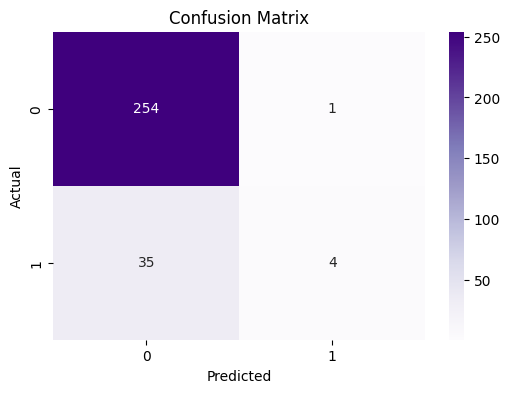

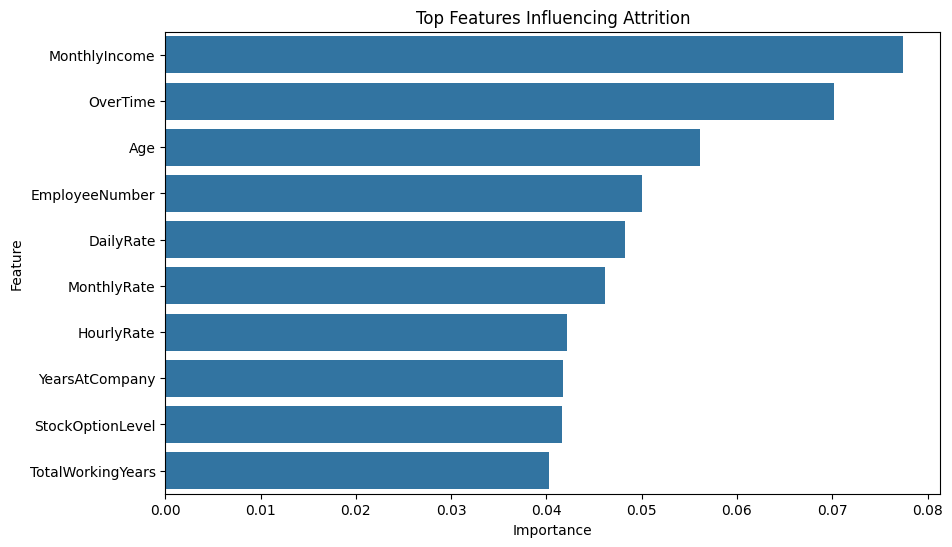

In [12]:

df_ml = df.copy()

# Label Encoding
label_encoder = LabelEncoder()

for column in df_ml.columns:
    if df_ml[column].dtype == 'object':
        df_ml[column] = label_encoder.fit_transform(df_ml[column])

X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(class_weight='balanced',random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top Features Influencing Attrition')

plt.show()

Distribusi kelas sebelum SMOTE: Attrition
0    978
1    198
Name: count, dtype: int64
Distribusi kelas setelah SMOTE: Attrition
0    978
1    978
Name: count, dtype: int64

--- Evaluasi Model Setelah SMOTE ---
Accuracy (SMOTE): 0.8605442176870748
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       255
           1       0.46      0.31      0.37        39

    accuracy                           0.86       294
   macro avg       0.68      0.63      0.65       294
weighted avg       0.84      0.86      0.85       294



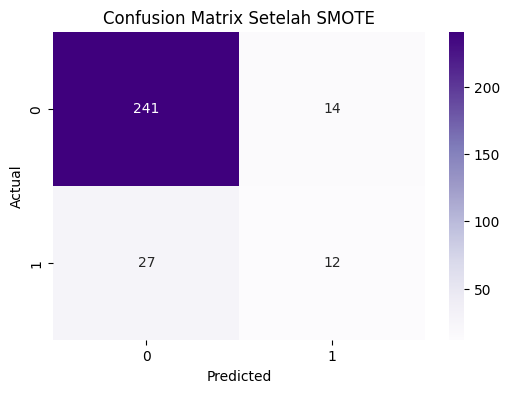

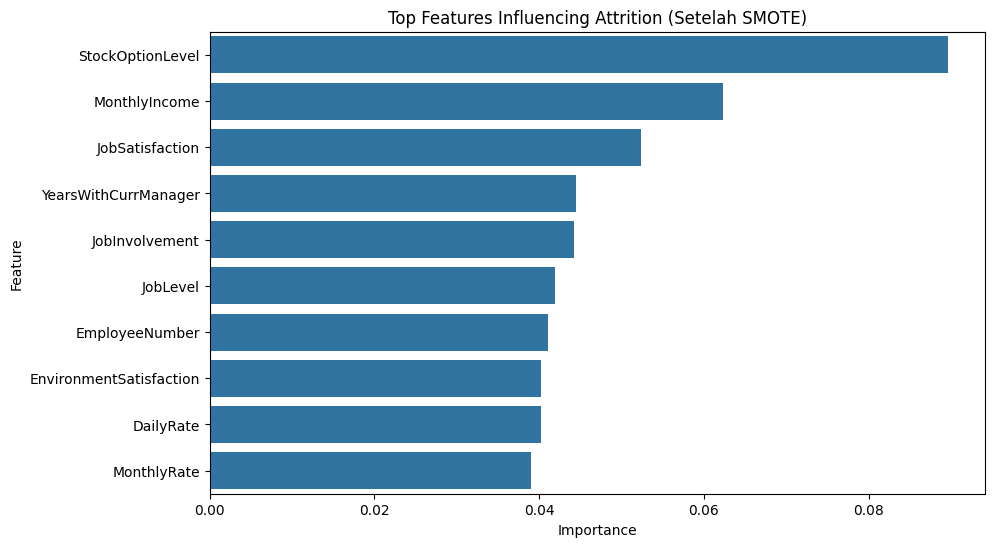

In [14]:
from imblearn.over_sampling import SMOTE

# Inisialisasi SMOTE
sm = SMOTE(random_state=42)

# Terapkan SMOTE pada data pelatihan
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print('Distribusi kelas sebelum SMOTE:', y_train.value_counts())
print('Distribusi kelas setelah SMOTE:', y_resampled.value_counts())

# Melatih ulang model dengan data yang sudah di-SMOTE
model_smote = RandomForestClassifier(class_weight='balanced', random_state=42)
model_smote.fit(X_resampled, y_resampled)

# Prediksi pada data uji
y_pred_smote = model_smote.predict(X_test)

# Evaluasi ulang model
print("\n--- Evaluasi Model Setelah SMOTE ---")
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print("Accuracy (SMOTE):", accuracy_smote)
print(classification_report(y_test, y_pred_smote))

# Confusion Matrix setelah SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix Setelah SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance setelah SMOTE
feature_importance_smote = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_smote.feature_importances_
})
feature_importance_smote = feature_importance_smote.sort_values(
    by='Importance',
    ascending=False
)

top_features_smote = feature_importance_smote.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features_smote
)
plt.title('Top Features Influencing Attrition (after SMOTE)')
plt.show()

## Model Evaluation Insights

The dataset was imbalanced, with significantly fewer attrition cases compared to non-attrition cases. SMOTE was applied to balance the classes before model training.

The Random Forest model achieved approximately 86% accuracy after SMOTE implementation. However, recall for attrition cases remained moderate, indicating that predicting employee resignation remains a challenging task.